In [1]:
from sklearn.datasets import fetch_openml
from sklearn.datasets import load_digits
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, silhouette_score
import Fstar

from sklearn.decomposition import PCA
import umap

import numpy as np
import pandas as pd
import requests
import zipfile
import imageio
import os
from PIL import Image
from glob import glob

import matplotlib.pyplot as plt
import seaborn as sns

import tripletclustering
import fast_hdbscan

# import networkx as nx
# import cdlib.algorithms as cd

sns.set()

In [2]:
digits = load_digits()
mnist = fetch_openml("MNIST_784")
usps = fetch_openml("USPS")

/Users/ryandewolfe/miniforge3/envs/tripletclustering/lib/python3.12/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name usps exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=41082
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=41964

  warn(warning_msg)


# Coil-20

In [ ]:
%%time
if not os.path.isfile('coil20.zip'):
    results = requests.get('http://www.cs.columbia.edu/CAVE/databases/SLAM_coil-20_coil-100/coil-20/coil-20-proc.zip')
    with open("coil20.zip", "wb") as code:
        code.write(results.content)

In [ ]:
import re
images_zip = zipfile.ZipFile('coil20.zip')
mylist = images_zip.namelist()
r = re.compile(".*\.png$")
filelist = list(filter(r.match, mylist))

In [ ]:
if not os.path.isfile('coil-20-proc/obj10__1.png'):
    !unzip coil20.zip

In [ ]:
%%time
coil_feature_vectors = []
for filename in filelist:
    im = imageio.imread(filename)
    coil_feature_vectors.append(im.flatten())
coil_20_data = np.asarray(coil_feature_vectors)
coil_20_target = pd.Series(filelist).str.extract("obj([0-9]+)", expand=False).values.astype(np.int32)

# Buildings

In [ ]:
if not os.path.isfile('buildings.rar'):
    results = requests.get('http://eprints.lincoln.ac.uk/id/eprint/16079/1/dataset.rar')
    with open('buildings.rar', "wb") as code:
        code.write(results.content)

In [ ]:
if not os.path.isfile('sheffield_buildings/Dataset/Dataset/1/S1-01.jpeg'):
    !rar x buildings.rar ./sheffield_buildings

In [ ]:
buildings_data = []
buildings_target = []
for i in range(1, 41):
    directory = f"sheffield_buildings/Dataset/{i}"
    images = np.vstack([np.asarray(Image.open(filename).resize((96, 96))).flatten() for filename in glob(f"{directory}/*")])
    labels = np.full(len(glob(f"{directory}/*")), i, dtype=np.int32)
    buildings_data.append(images)
    buildings_target.append(labels)
buildings_data = np.vstack(buildings_data)
buildings_target = np.hstack(buildings_target)

# Cluster evaluation

In [3]:
def eval_clusters(cluster_labels, true_labels, raw_data, cluster_method="None", min_cluster_size=5):
    clustered_points = (cluster_labels >= 0)
    ari = adjusted_rand_score(true_labels[clustered_points], cluster_labels[clustered_points])
    ami = adjusted_mutual_info_score(true_labels[clustered_points], cluster_labels[clustered_points])
    fs = Fstar.fstar(true_labels, cluster_labels, outliers=False, alpha=0)
    pct_clustered = (np.sum(clustered_points) / cluster_labels.shape[0])
    print(f"ARI: {ari:.4f}\nAMI: {ami:.4f}\nPct clustered: {pct_clustered * 100:.2f}%")
    
    return {"Method": cluster_method, "ARI": ari, "AMI": ami, "F*": fs, "Pct Clustered": pct_clustered}

In [4]:
def plot_scores(results_dataframe, score_types=("ARI", "AMI", "F*"), colors=list(sns.color_palette()), width=0.75):
    fig, axs = plt.subplots(1, len(score_types), figsize=(10 * len(score_types), 8))
    x_ticklabels = results_dataframe.Method.unique()
    x_positions = np.arange(len(x_ticklabels), dtype=np.float32) - width / 2
    dim_red_types = results_dataframe["Dim Reduction"].unique()
    bar_width = width / len(dim_red_types)
    for offset_idx, dim_red in enumerate(dim_red_types):
        color = colors[offset_idx]
        for i, score_type in enumerate(score_types):
            sub_dataframe = results_dataframe[
                (results_dataframe["Score Type"] == score_type) &
                (results_dataframe["Dim Reduction"] == dim_red)
            ]
            axs[i].bar(
                x=x_positions,
                height=sub_dataframe["Score"],
                width=bar_width,
                align="edge",
                color=[(*color, v) for v in sub_dataframe["Pct Clustered"]],
                label=dim_red if i ==0 else None,
            )
            axs[i].set_xlabel("Cluster Method")
            axs[i].set_xticks(np.arange(len(x_ticklabels)))
            axs[i].set_xticklabels(x_ticklabels)
            axs[i].set_ylabel(f"{score_type} Score")
            axs[i].set_title(score_type, fontsize=20)
            axs[i].grid(visible=False, axis="x")
            axs[i].set_ylim([0, 1.05])
        x_positions += bar_width
        
    if len(dim_red_types) > 1:
        fig.legend(loc="center right", bbox_to_anchor=(1.125, 0.5), borderaxespad=0.0, fontsize=20)
        
    fig.tight_layout()

# Choose the Data

In [7]:
data = digits.data.astype(np.float32)
labels = digits.target
#labels = digits.target.values.astype(np.int64)  # Sometime targets are a pandas series
data.shape

(1797, 64)

# Cluster on the Data Directly

In [9]:
%%time
ms = 100
rbl_eom_labels = tripletclustering.TripletClustering(similarity_method="rbl", cluster_selection_method="eom", min_cluster_size=ms, metric="cosine").fit_predict(data)
rbl_pl_labels = tripletclustering.TripletClustering(similarity_method="rbl", cluster_selection_method="pl", min_cluster_size=ms, metric="cosine").fit_predict(data)
rbl_flat_labels = tripletclustering.TripletClustering(similarity_method="rbl", cluster_selection_method="flat", min_cluster_size=ms, metric="cosine").fit_predict(data)

paknnld_eom_labels = tripletclustering.TripletClustering(similarity_method="paknnld", cluster_selection_method="eom", min_cluster_size=ms, metric="cosine").fit_predict(data)
paknnld_pl_labels = tripletclustering.TripletClustering(similarity_method="paknnld", cluster_selection_method="pl", min_cluster_size=ms, metric="cosine").fit_predict(data)

hd_eom_labels = fast_hdbscan.HDBSCAN(min_samples=5, min_cluster_size=ms).fit_predict(data)
hd_pl_labels = fast_hdbscan.PLSCAN(min_samples=5, base_min_cluster_size=ms).fit_predict(data)

CPU times: user 25.1 s, sys: 974 ms, total: 26.1 s
Wall time: 24.2 s


In [10]:
raw_results = pd.DataFrame(
    [
        eval_clusters(rbl_eom_labels, labels, data, cluster_method="RBL-EOM"),
        eval_clusters(rbl_pl_labels, labels, data, cluster_method="RBL-PL"),
        eval_clusters(rbl_flat_labels, labels, data, cluster_method="RBL-FLAT"),
        eval_clusters(paknnld_eom_labels, labels, data, cluster_method="PAKNNLD-EOM"),
        eval_clusters(paknnld_pl_labels, labels, data, cluster_method="PAKNNLD-PL"),
        eval_clusters(hd_eom_labels, labels, data, cluster_method="HDBSCAN-EOM"),
        eval_clusters(hd_pl_labels, labels, data, cluster_method="HDBSCAN-PL"),
    ]
)
raw_results_long = raw_results.melt(["Method", "Pct Clustered"], var_name="Score Type", value_name="Score")
raw_results_long["Dim Reduction"] = "None"

ARI: 0.0439
AMI: 0.2350
Pct clustered: 85.81%
ARI: 0.1219
AMI: 0.4395
Pct clustered: 66.33%
ARI: 0.0443
AMI: 0.2362
Pct clustered: 87.48%
ARI: 0.5325
AMI: 0.7951
Pct clustered: 69.39%
ARI: 0.6194
AMI: 0.8192
Pct clustered: 62.66%
ARI: 0.3160
AMI: 0.7109
Pct clustered: 80.52%
ARI: 0.7893
AMI: 0.9128
Pct clustered: 70.34%


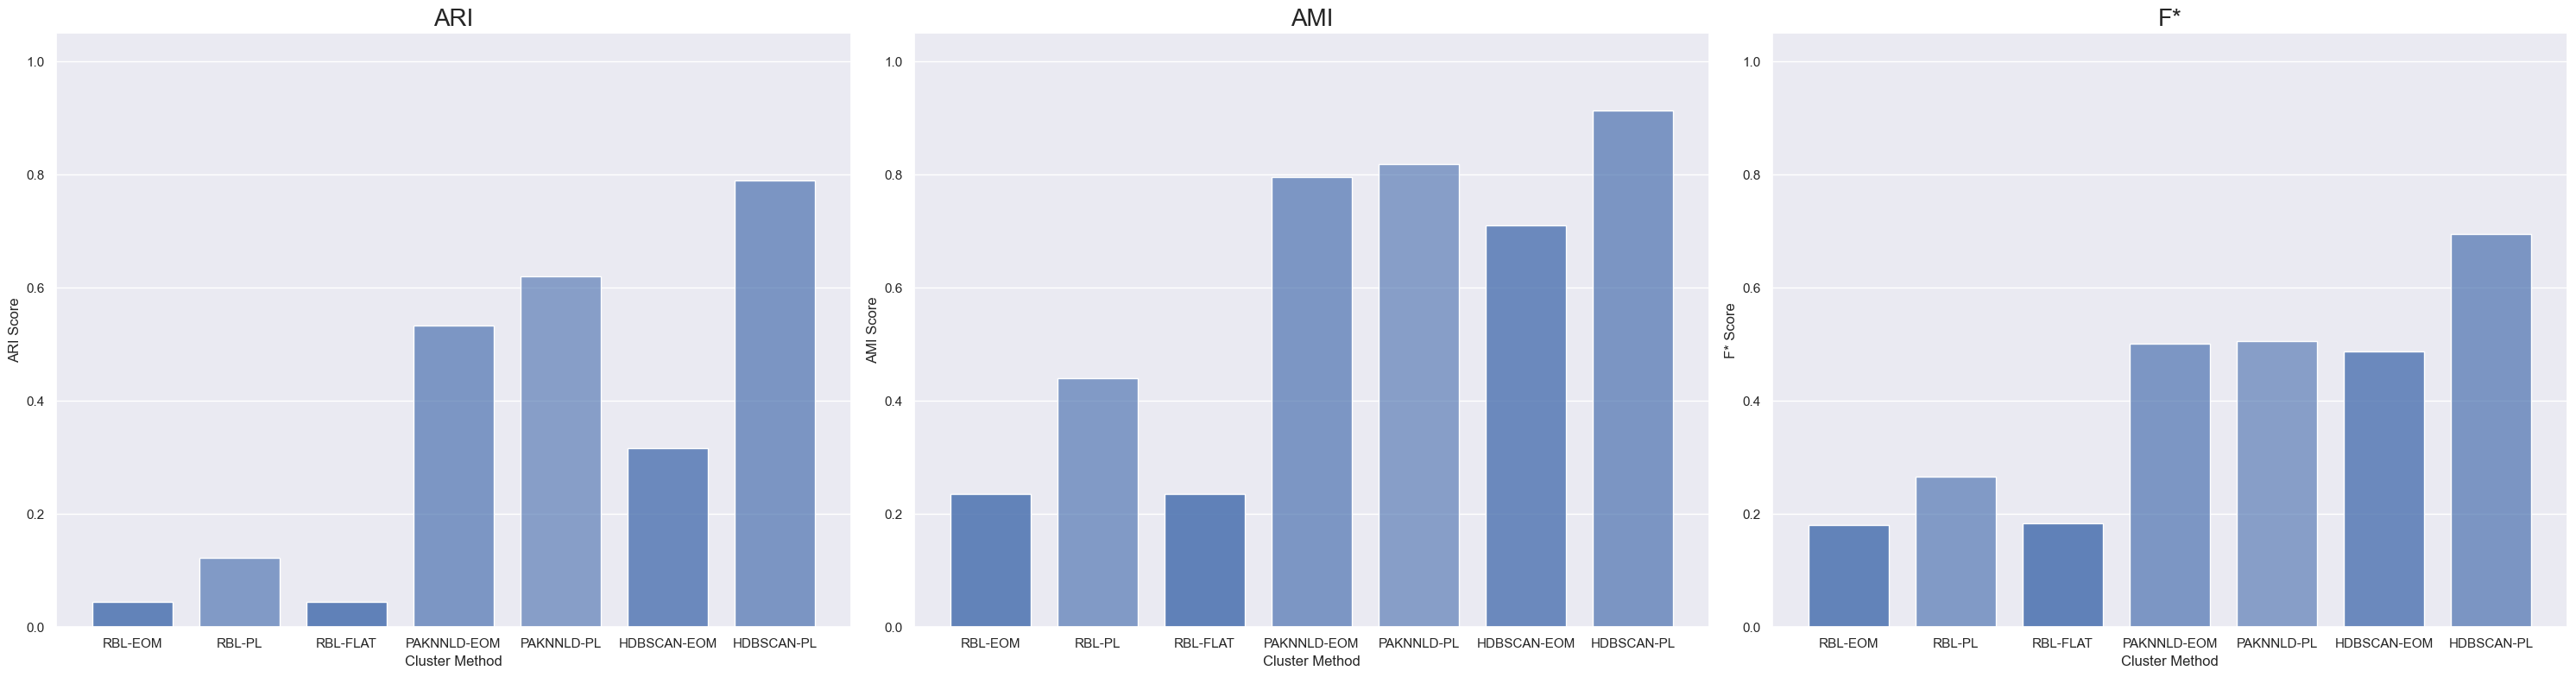

In [11]:
plot_scores(raw_results_long)

# Cluster on PCA reduction to 16 dimensions

In [12]:
pca_data = PCA(n_components=16).fit_transform(data)

In [13]:
%%time
ms = 100
rbl_eom_pca_labels = tripletclustering.TripletClustering(similarity_method="rbl", cluster_selection_method="eom", min_cluster_size=ms, metric="cosine").fit_predict(pca_data)
rbl_pl_pca_labels = tripletclustering.TripletClustering(similarity_method="rbl", cluster_selection_method="pl", min_cluster_size=ms, metric="cosine").fit_predict(pca_data)
rbl_flat_pca_labels = tripletclustering.TripletClustering(similarity_method="rbl", cluster_selection_method="flat", min_cluster_size=ms, metric="cosine").fit_predict(pca_data)

paknnld_eom_pca_labels = tripletclustering.TripletClustering(similarity_method="paknnld", cluster_selection_method="eom", min_cluster_size=ms, metric="cosine").fit_predict(pca_data)
paknnld_pl_pca_labels = tripletclustering.TripletClustering(similarity_method="paknnld", cluster_selection_method="pl", min_cluster_size=ms, metric="cosine").fit_predict(pca_data)

hd_eom_pca_labels = fast_hdbscan.HDBSCAN(min_samples=5, min_cluster_size=ms).fit_predict(pca_data)
hd_pl_pca_labels = fast_hdbscan.PLSCAN(min_samples=5, base_min_cluster_size=ms).fit_predict(pca_data)

CPU times: user 5.85 s, sys: 121 ms, total: 5.98 s
Wall time: 3.75 s


In [14]:
pca_results = pd.DataFrame(
    [
        eval_clusters(rbl_eom_pca_labels, labels, pca_data, cluster_method="RBL-EOM"),
        eval_clusters(rbl_pl_pca_labels, labels, pca_data, cluster_method="RBL-PL"),
        eval_clusters(rbl_flat_pca_labels, labels, pca_data, cluster_method="RBL-FLAT"),
        eval_clusters(paknnld_eom_pca_labels, labels, pca_data, cluster_method="PAKNNLD-EOM"),
        eval_clusters(paknnld_pl_pca_labels, labels, pca_data, cluster_method="PAKNNLD-PL"),
        eval_clusters(hd_eom_pca_labels, labels, pca_data, cluster_method="HDBSCAN-EOM"),
        eval_clusters(hd_pl_pca_labels, labels, pca_data, cluster_method="HDBSCAN-PL"),
    ]
)
pca_results_long = pca_results.melt(["Method", "Pct Clustered"], var_name="Score Type", value_name="Score")
pca_results_long["Dim Reduction"] = "PCA"

ARI: 0.0441
AMI: 0.2361
Pct clustered: 95.33%
ARI: 0.5668
AMI: 0.7214
Pct clustered: 31.11%
ARI: 0.0440
AMI: 0.2338
Pct clustered: 95.60%
ARI: 0.3085
AMI: 0.6687
Pct clustered: 67.39%
ARI: 0.6067
AMI: 0.7914
Pct clustered: 63.61%
ARI: 0.7797
AMI: 0.9024
Pct clustered: 72.68%
ARI: 0.7794
AMI: 0.9023
Pct clustered: 72.62%


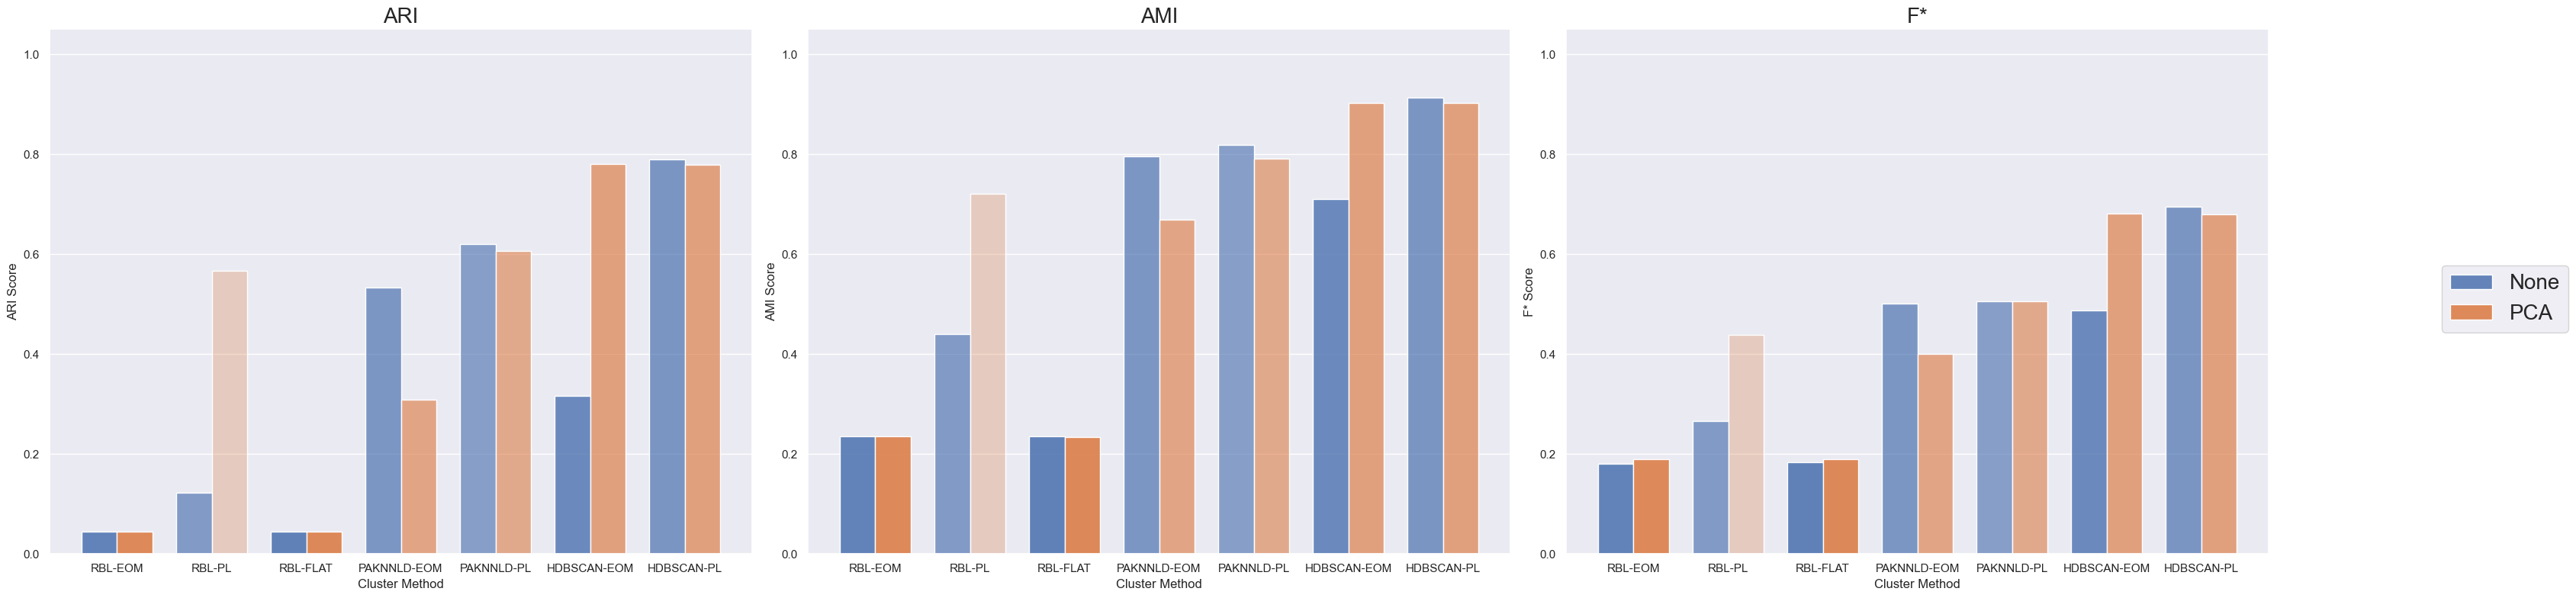

In [15]:
plot_scores(pd.concat([raw_results_long, pca_results_long]))

# Cluster on UMAP reduction to 4 dimensions

In [16]:
umap_data = umap.UMAP(n_components=4, min_dist=1e-8, random_state=0).fit_transform(data)

/Users/ryandewolfe/miniforge3/envs/tripletclustering/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [17]:
%%time
ms = 100
rbl_eom_umap_labels = tripletclustering.TripletClustering(similarity_method="rbl", cluster_selection_method="eom", min_cluster_size=ms, metric="euclidean").fit_predict(umap_data)
rbl_pl_umap_labels = tripletclustering.TripletClustering(similarity_method="rbl", cluster_selection_method="pl", min_cluster_size=ms, metric="euclidean").fit_predict(umap_data)
rbl_flat_umap_labels = tripletclustering.TripletClustering(similarity_method="rbl", cluster_selection_method="flat", min_cluster_size=ms, metric="euclidean").fit_predict(umap_data)

paknnld_eom_umap_labels = tripletclustering.TripletClustering(similarity_method="paknnld", cluster_selection_method="eom", min_cluster_size=ms, metric="euclidean").fit_predict(umap_data)
paknnld_pl_umap_labels = tripletclustering.TripletClustering(similarity_method="paknnld", cluster_selection_method="pl", min_cluster_size=ms, metric="euclidean").fit_predict(umap_data)

hd_eom_umap_labels = fast_hdbscan.HDBSCAN(min_samples=5, min_cluster_size=ms).fit_predict(umap_data)
hd_pl_umap_labels = fast_hdbscan.PLSCAN(min_samples=5, base_min_cluster_size=ms).fit_predict(umap_data)

CPU times: user 6.41 s, sys: 124 ms, total: 6.53 s
Wall time: 4.38 s


In [18]:
umap_results = pd.DataFrame(
    [
        eval_clusters(rbl_eom_umap_labels, labels, umap_data, cluster_method="RBL-EOM"),
        eval_clusters(rbl_pl_umap_labels, labels, umap_data, cluster_method="RBL-PL"),
        eval_clusters(rbl_flat_umap_labels, labels, umap_data, cluster_method="RBL-FLAT"),
        eval_clusters(paknnld_eom_umap_labels, labels, umap_data, cluster_method="PAKNNLD-EOM"),
        eval_clusters(paknnld_pl_umap_labels, labels, umap_data, cluster_method="PAKNNLD-PL"),
        eval_clusters(hd_eom_umap_labels, labels, umap_data, cluster_method="HDBSCAN-EOM"),
        eval_clusters(hd_pl_umap_labels, labels, umap_data, cluster_method="HDBSCAN-PL"),
    ]
)
umap_results_long = umap_results.melt(["Method", "Pct Clustered"], var_name="Score Type", value_name="Score")
umap_results_long["Dim Reduction"] = "UMAP"

ARI: 0.9621
AMI: 0.9628
Pct clustered: 92.04%
ARI: 0.9413
AMI: 0.9482
Pct clustered: 96.22%
ARI: 1.0000
AMI: 1.0000
Pct clustered: 0.00%
ARI: 0.9417
AMI: 0.9491
Pct clustered: 94.88%
ARI: 0.9417
AMI: 0.9491
Pct clustered: 94.88%
ARI: 0.9501
AMI: 0.9539
Pct clustered: 97.38%
ARI: 0.7653
AMI: 0.8832
Pct clustered: 98.50%


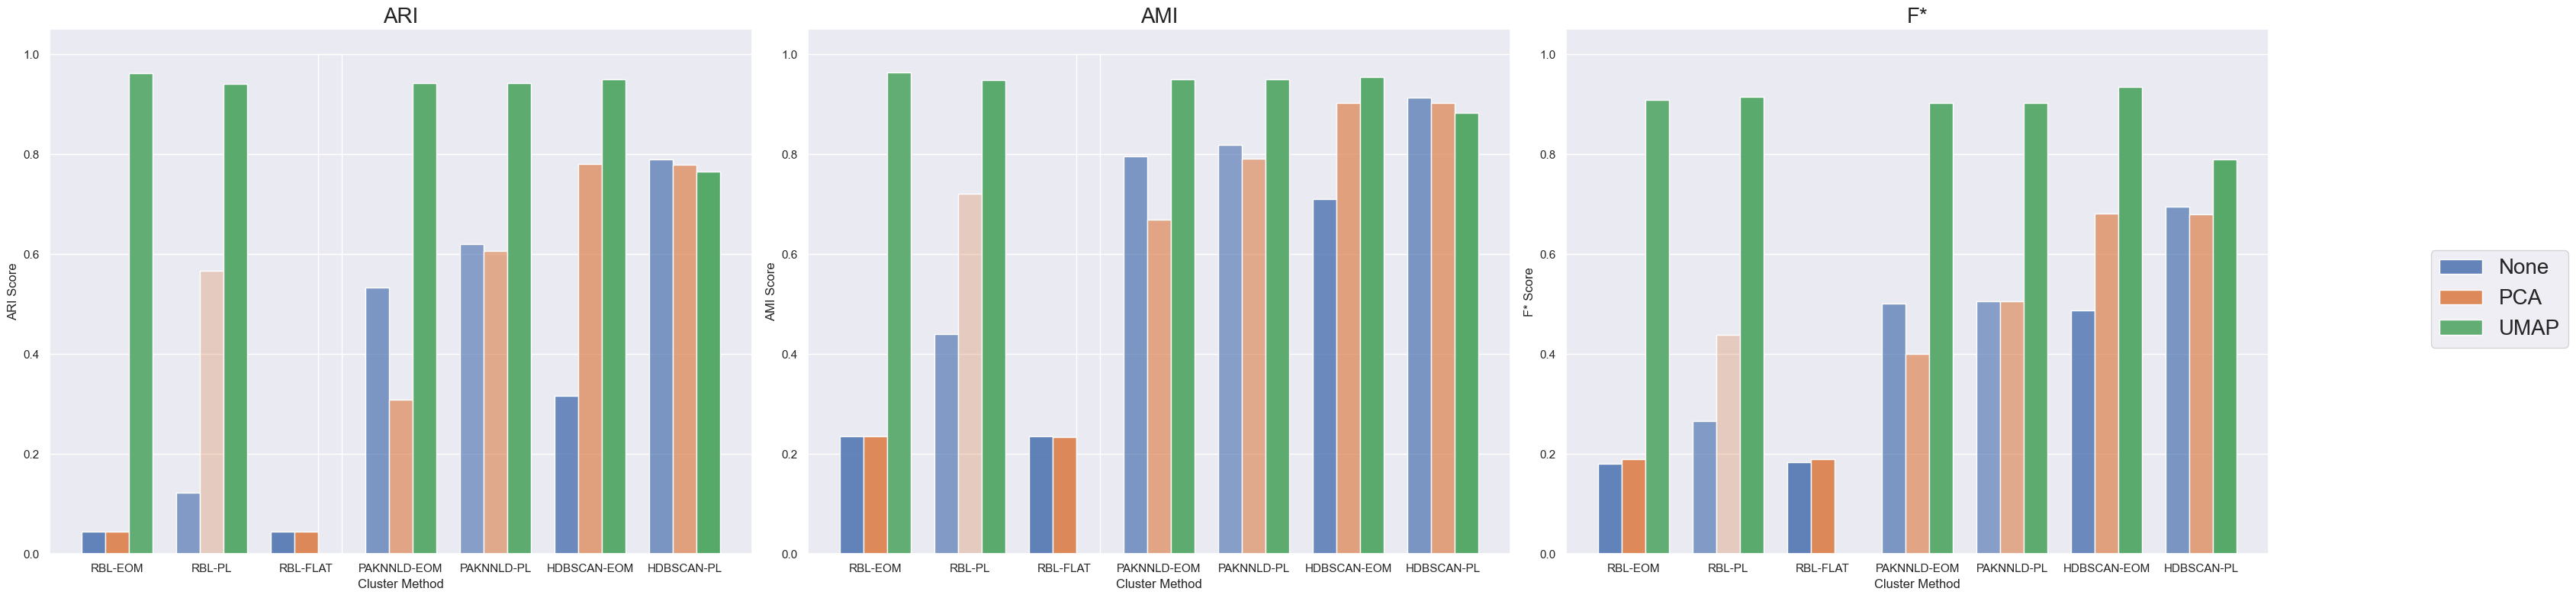

In [19]:
plot_scores(pd.concat([raw_results_long, pca_results_long, umap_results_long]))